# EDA Question 3: Customer Segmentation Analysis (RFM)
## Amazon India Sales Analytics

**Objective:** Build a customer segmentation analysis using RFM (Recency, Frequency, Monetary) methodology. Create scatter plots and segment customers into meaningful groups with actionable insights.

**Analysis Components:**
- RFM metric calculation for each customer
- RFM score assignment and segmentation
- Customer segment identification
- Scatter plot visualizations (2D and 3D)
- Segment profiling and characteristics
- Actionable insights and recommendations

## Section 1: Load Data and Setup

Import required libraries and load the cleaned dataset for RFM analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the cleaned dataset
df = pd.read_csv('../data/cleaned/amazon_india_all_years_cleaned.csv')

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Display basic information
print("Dataset Shape:", df.shape)
print(f"\nDate Range: {df['order_date'].min()} to {df['order_date'].max()}")
print(f"Total Records: {len(df):,}")
print(f"Unique Customers: {df['customer_id'].nunique():,}")
print(f"\nColumns for RFM Analysis:")
print("  • customer_id")
print("  • order_date")
print("  • transaction_id")
print("  • final_amount_inr")
print("\n✓ Data loaded successfully")

Dataset Shape: (1122687, 51)

Date Range: 2015-01-01 00:00:00 to 2025-12-31 00:00:00
Total Records: 1,122,687
Unique Customers: 354,969

Columns for RFM Analysis:
  • customer_id
  • order_date
  • transaction_id
  • final_amount_inr

✓ Data loaded successfully


## Section 2: Calculate RFM Metrics

Calculate Recency, Frequency, and Monetary values for each customer.

In [3]:
# Set the reference date (most recent date in dataset + 1 day)
reference_date = df['order_date'].max() + timedelta(days=1)
print(f"Reference Date for Recency Calculation: {reference_date.date()}")
print("=" * 100)

# Calculate RFM metrics
rfm_data = df.groupby('customer_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,  # Recency
    'transaction_id': 'count',  # Frequency
    'final_amount_inr': 'sum'  # Monetary
}).reset_index()

# Rename columns
rfm_data.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# Add additional metrics
rfm_data['Avg_Order_Value'] = rfm_data['Monetary'] / rfm_data['Frequency']

print("\n" + "=" * 100)
print("RFM METRICS SUMMARY")
print("=" * 100)
print(f"\nTotal Customers Analyzed: {len(rfm_data):,}")
print("\nRFM Statistics:")
print(rfm_data[['Recency', 'Frequency', 'Monetary']].describe().round(2))

print("\n" + "-" * 100)
print("Sample RFM Data (Top 10):")
print("-" * 100)
print(rfm_data.nlargest(10, 'Monetary').to_string(index=False))

print("\n✓ RFM metrics calculated successfully")

Reference Date for Recency Calculation: 2026-01-01

RFM METRICS SUMMARY

Total Customers Analyzed: 354,969

RFM Statistics:
         Recency  Frequency    Monetary
count  354969.00  354969.00   354969.00
mean     1361.83       3.16   215645.78
std       863.47       2.34   237474.53
min         1.00       1.00      582.16
25%       644.00       1.00    63735.55
50%      1258.00       2.00   137975.85
75%      1977.00       4.00   279307.03
max      4015.00      27.00  3757087.02

----------------------------------------------------------------------------------------------------
Sample RFM Data (Top 10):
----------------------------------------------------------------------------------------------------
       customer_id  Recency  Frequency   Monetary  Avg_Order_Value
CUST_2015_00003928     1465         27 3757087.02    139151.371111
CUST_2016_00007974      997         17 3708826.25    218166.250000
CUST_2016_00001495      762         20 3533620.11    176681.005500
CUST_2018_00007329 

## Section 3: RFM Score Assignment

Assign scores (1-5) to each RFM metric using quintiles, then create combined RFM scores.

In [4]:
# Assign RFM scores using quintiles (1-5)
# For Recency: lower is better (recent customers get higher scores)
# For Frequency and Monetary: higher is better

rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Convert to integers
rfm_data['R_Score'] = rfm_data['R_Score'].astype(int)
rfm_data['F_Score'] = rfm_data['F_Score'].astype(int)
rfm_data['M_Score'] = rfm_data['M_Score'].astype(int)

# Calculate combined RFM Score
rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str) + rfm_data['M_Score'].astype(str)

# Calculate weighted RFM Score (for overall ranking)
rfm_data['RFM_Score_Weighted'] = (rfm_data['R_Score'] * 0.3 + 
                                   rfm_data['F_Score'] * 0.35 + 
                                   rfm_data['M_Score'] * 0.35)

print("=" * 100)
print("RFM SCORE DISTRIBUTION")
print("=" * 100)

print("\nRecency Score Distribution:")
print(rfm_data['R_Score'].value_counts().sort_index())

print("\nFrequency Score Distribution:")
print(rfm_data['F_Score'].value_counts().sort_index())

print("\nMonetary Score Distribution:")
print(rfm_data['M_Score'].value_counts().sort_index())

print("\n" + "-" * 100)
print("Top 10 Customers by Weighted RFM Score:")
print("-" * 100)
top_customers = rfm_data.nlargest(10, 'RFM_Score_Weighted')[['customer_id', 'Recency', 'Frequency', 'Monetary', 
                                                                'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Score_Weighted']]
print(top_customers.to_string(index=False))

print("\n✓ RFM scores assigned successfully")

RFM SCORE DISTRIBUTION

Recency Score Distribution:
R_Score
1    70857
2    71069
3    71035
4    70893
5    71115
Name: count, dtype: int64

Frequency Score Distribution:
F_Score
1    70994
2    70994
3    70993
4    70994
5    70994
Name: count, dtype: int64

Monetary Score Distribution:
M_Score
1    70994
2    70994
3    70993
4    70994
5    70994
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------
Top 10 Customers by Weighted RFM Score:
----------------------------------------------------------------------------------------------------
       customer_id  Recency  Frequency   Monetary  R_Score  F_Score  M_Score RFM_Score  RFM_Score_Weighted
CUST_2015_00000006      413         11 2192722.94        5        5        5       555                 5.0
CUST_2015_00000111      414         14  397742.73        5        5        5       555                 5.0
CUST_2015_00000138      386          8  709918.16       

## Section 4: Customer Segmentation

Create meaningful customer segments based on RFM scores with actionable labels.

In [5]:
# Define segmentation logic based on RFM scores
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    # Champions: Best customers (high RFM)
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    
    # Loyal Customers: Frequent buyers (high F, good M)
    elif f >= 4 and m >= 3:
        return 'Loyal Customers'
    
    # Potential Loyalists: Recent customers with potential (high R, moderate FM)
    elif r >= 4 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    
    # Recent Customers: New or returning recent customers
    elif r >= 4:
        return 'Recent Customers'
    
    # Promising: Mid-range customers (moderate RFM)
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Promising'
    
    # Need Attention: Declining customers (low R, good FM)
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Need Attention'
    
    # At Risk: Were good customers but churning (low R, high FM historically)
    elif r <= 2 and f >= 3:
        return 'At Risk'
    
    # Can't Lose Them: High value but haven't purchased recently
    elif r <= 2 and m >= 4:
        return "Can't Lose Them"
    
    # Hibernating: Low engagement (low R, low F)
    elif r <= 2 and f <= 2:
        return 'Hibernating'
    
    # Lost: Likely churned customers
    elif r == 1:
        return 'Lost'
    
    # Others: Doesn't fit clear patterns
    else:
        return 'Others'

# Apply segmentation
rfm_data['Segment'] = rfm_data.apply(assign_segment, axis=1)

# Segment statistics
segment_summary = rfm_data.groupby('Segment').agg({
    'customer_id': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Score_Weighted': 'mean'
}).reset_index()

segment_summary.columns = ['Segment', 'Customer_Count', 'Avg_Recency', 'Avg_Frequency', 
                           'Avg_Monetary', 'Avg_RFM_Score']

# Calculate percentages
total_customers = len(rfm_data)
segment_summary['Percentage'] = (segment_summary['Customer_Count'] / total_customers * 100).round(2)

# Calculate total revenue per segment
segment_summary['Total_Revenue'] = segment_summary['Customer_Count'] * segment_summary['Avg_Monetary']

# Sort by customer count
segment_summary = segment_summary.sort_values('Customer_Count', ascending=False)

print("=" * 100)
print("CUSTOMER SEGMENTATION SUMMARY")
print("=" * 100)
print(f"\nTotal Customers: {total_customers:,}")
print(f"Total Segments: {rfm_data['Segment'].nunique()}")
print("\n" + "-" * 100)
print("Segment Details:")
print("-" * 100)
print(segment_summary.to_string(index=False))

print("\n✓ Customer segmentation complete")

CUSTOMER SEGMENTATION SUMMARY

Total Customers: 354,969
Total Segments: 10

----------------------------------------------------------------------------------------------------
Segment Details:
----------------------------------------------------------------------------------------------------
            Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_RFM_Score  Percentage  Total_Revenue
    Loyal Customers           85893  1628.587592       5.407926 373949.269717       3.775557       24.20   3.211962e+10
        Hibernating           60496  2263.366388       1.411052  74268.021801       1.595833       17.04   4.492918e+09
Potential Loyalists           46583   494.741751       2.227765 129429.455236       3.326874       13.12   6.029212e+09
          Champions           41014   499.500414       5.756181 436793.947572       4.557797       11.55   1.791467e+10
   Recent Customers           39109   544.937227       1.321588  41416.818543       2.428444       11.02 

## Section 5: RFM Distribution Visualizations

Create visualizations showing the distribution of RFM metrics and scores.

✓ RFM distribution visualizations saved as 'Q03_RFM_Distribution_Overview.png'


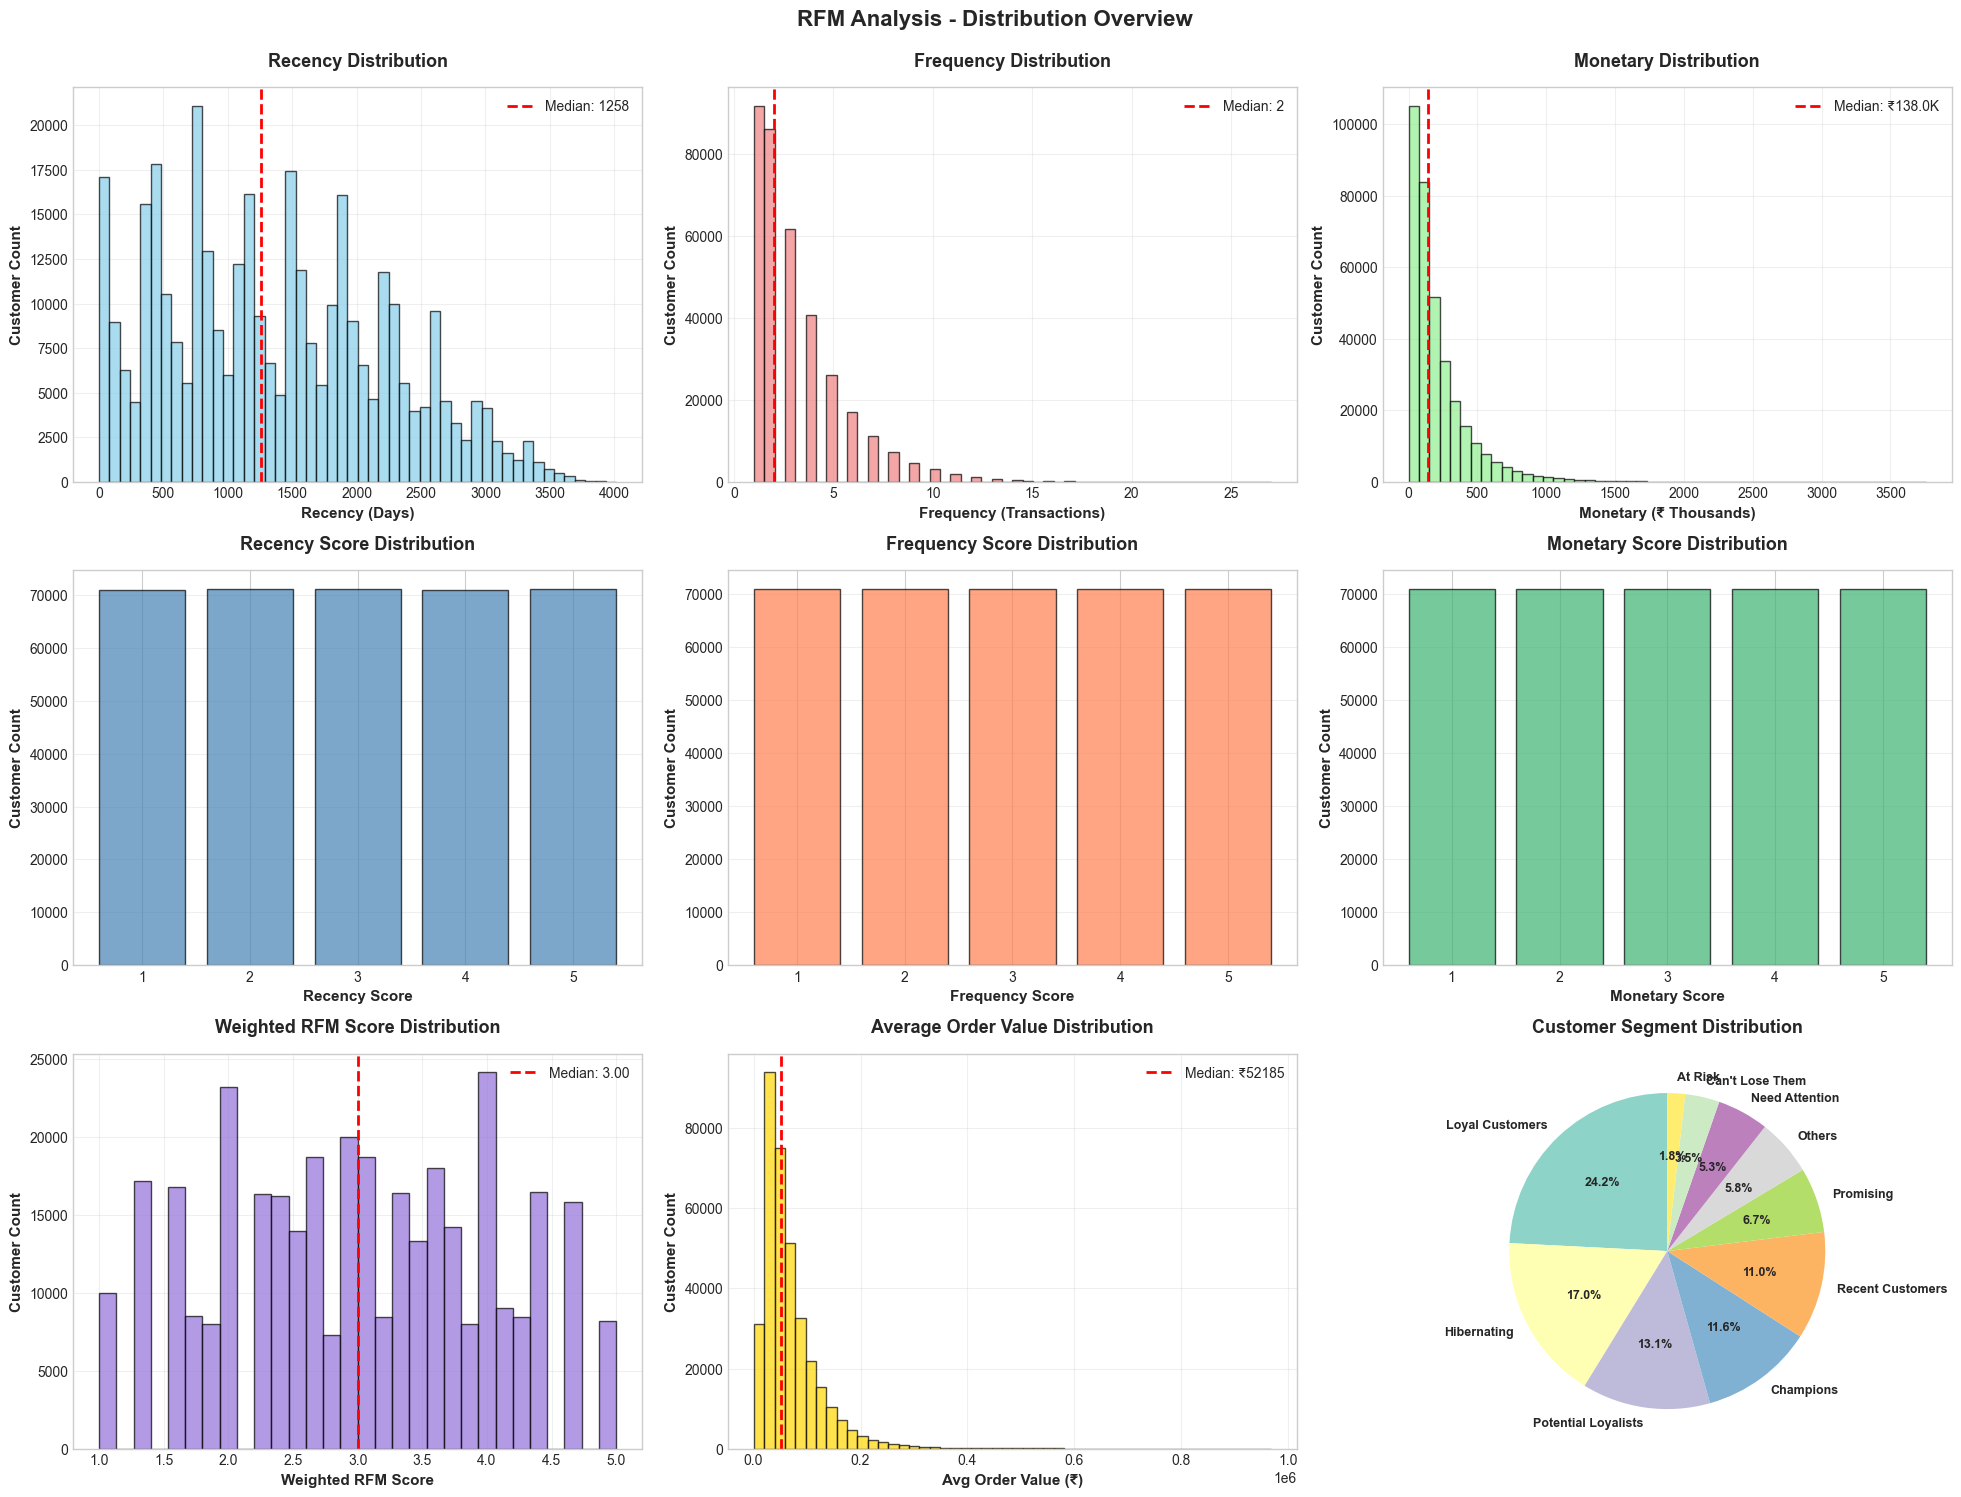

In [6]:
# Create comprehensive distribution plots
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# Row 1: RFM Metrics Distribution
# Recency Distribution
axes[0, 0].hist(rfm_data['Recency'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Recency (Days)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Customer Count', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Recency Distribution', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].axvline(rfm_data['Recency'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {rfm_data["Recency"].median():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Frequency Distribution
axes[0, 1].hist(rfm_data['Frequency'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Frequency (Transactions)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Customer Count', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Frequency Distribution', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].axvline(rfm_data['Frequency'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {rfm_data["Frequency"].median():.0f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Monetary Distribution
axes[0, 2].hist(rfm_data['Monetary']/1000, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Monetary (₹ Thousands)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Customer Count', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Monetary Distribution', fontsize=13, fontweight='bold', pad=15)
axes[0, 2].axvline(rfm_data['Monetary'].median()/1000, color='red', linestyle='--', linewidth=2, label=f'Median: ₹{rfm_data["Monetary"].median()/1000:.1f}K')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Row 2: RFM Score Distribution
# R-Score
r_counts = rfm_data['R_Score'].value_counts().sort_index()
axes[1, 0].bar(r_counts.index, r_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Recency Score', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Customer Count', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Recency Score Distribution', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].set_xticks(range(1, 6))
axes[1, 0].grid(True, alpha=0.3, axis='y')

# F-Score
f_counts = rfm_data['F_Score'].value_counts().sort_index()
axes[1, 1].bar(f_counts.index, f_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Frequency Score', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Customer Count', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Frequency Score Distribution', fontsize=13, fontweight='bold', pad=15)
axes[1, 1].set_xticks(range(1, 6))
axes[1, 1].grid(True, alpha=0.3, axis='y')

# M-Score
m_counts = rfm_data['M_Score'].value_counts().sort_index()
axes[1, 2].bar(m_counts.index, m_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Monetary Score', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('Customer Count', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Monetary Score Distribution', fontsize=13, fontweight='bold', pad=15)
axes[1, 2].set_xticks(range(1, 6))
axes[1, 2].grid(True, alpha=0.3, axis='y')

# Row 3: Combined Analysis
# Weighted RFM Score
axes[2, 0].hist(rfm_data['RFM_Score_Weighted'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[2, 0].set_xlabel('Weighted RFM Score', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Customer Count', fontsize=11, fontweight='bold')
axes[2, 0].set_title('Weighted RFM Score Distribution', fontsize=13, fontweight='bold', pad=15)
axes[2, 0].axvline(rfm_data['RFM_Score_Weighted'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {rfm_data["RFM_Score_Weighted"].median():.2f}')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# Average Order Value
axes[2, 1].hist(rfm_data['Avg_Order_Value'], bins=50, color='gold', edgecolor='black', alpha=0.7)
axes[2, 1].set_xlabel('Avg Order Value (₹)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Customer Count', fontsize=11, fontweight='bold')
axes[2, 1].set_title('Average Order Value Distribution', fontsize=13, fontweight='bold', pad=15)
axes[2, 1].axvline(rfm_data['Avg_Order_Value'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: ₹{rfm_data["Avg_Order_Value"].median():.0f}')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

# Segment Distribution (Pie)
segment_counts = rfm_data['Segment'].value_counts()
colors_custom = plt.cm.Set3(np.linspace(0, 1, len(segment_counts)))
axes[2, 2].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
               colors=colors_custom, startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
axes[2, 2].set_title('Customer Segment Distribution', fontsize=13, fontweight='bold', pad=15)

plt.suptitle('RFM Analysis - Distribution Overview', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../data/cleaned/Q03_RFM_Distribution_Overview.png', dpi=300, bbox_inches='tight')
print("✓ RFM distribution visualizations saved as 'Q03_RFM_Distribution_Overview.png'")
plt.show()

## Section 6: 2D Scatter Plot Analysis

Create scatter plots showing relationships between RFM metrics with customer segments.


✓ 2D scatter plots saved as 'Q03_RFM_2D_Scatter_Plots.png'


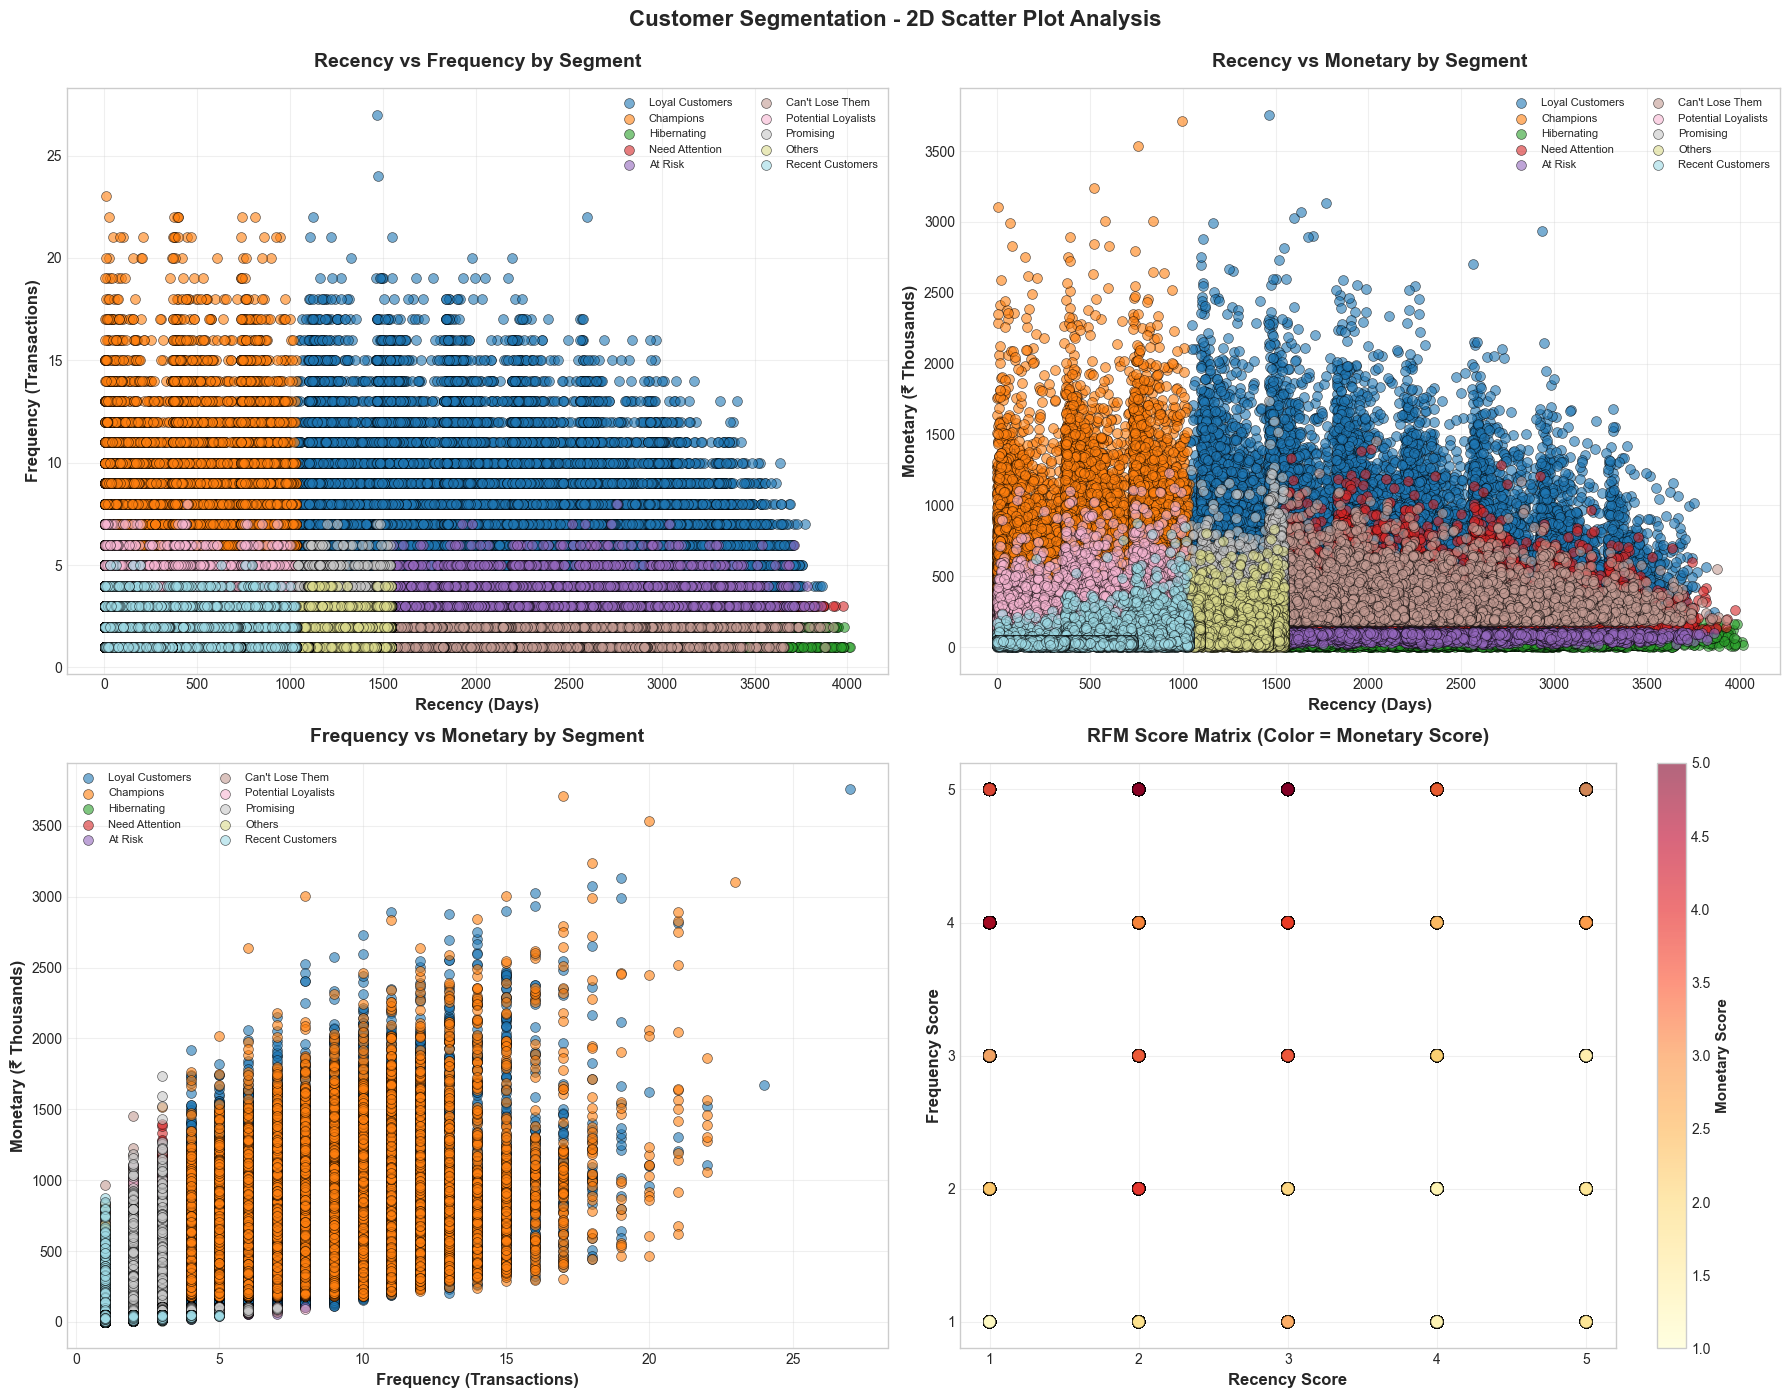

In [7]:
# Create 2D scatter plots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Get unique segments and assign colors
segments = rfm_data['Segment'].unique()
colors_palette = plt.cm.tab20(np.linspace(0, 1, len(segments)))
segment_colors = {segment: colors_palette[i] for i, segment in enumerate(segments)}

# Plot 1: Recency vs Frequency
ax1 = axes[0, 0]
for segment in segments:
    segment_data = rfm_data[rfm_data['Segment'] == segment]
    ax1.scatter(segment_data['Recency'], segment_data['Frequency'], 
                c=[segment_colors[segment]], label=segment, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Recency (Days)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency (Transactions)', fontsize=12, fontweight='bold')
ax1.set_title('Recency vs Frequency by Segment', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# Plot 2: Recency vs Monetary
ax2 = axes[0, 1]
for segment in segments:
    segment_data = rfm_data[rfm_data['Segment'] == segment]
    ax2.scatter(segment_data['Recency'], segment_data['Monetary']/1000, 
                c=[segment_colors[segment]], label=segment, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Recency (Days)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Monetary (₹ Thousands)', fontsize=12, fontweight='bold')
ax2.set_title('Recency vs Monetary by Segment', fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='best', fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3)

# Plot 3: Frequency vs Monetary
ax3 = axes[1, 0]
for segment in segments:
    segment_data = rfm_data[rfm_data['Segment'] == segment]
    ax3.scatter(segment_data['Frequency'], segment_data['Monetary']/1000, 
                c=[segment_colors[segment]], label=segment, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax3.set_xlabel('Frequency (Transactions)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Monetary (₹ Thousands)', fontsize=12, fontweight='bold')
ax3.set_title('Frequency vs Monetary by Segment', fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc='best', fontsize=8, ncol=2)
ax3.grid(True, alpha=0.3)

# Plot 4: RFM Score Heatmap (R vs F with M as color)
ax4 = axes[1, 1]
scatter = ax4.scatter(rfm_data['R_Score'], rfm_data['F_Score'], 
                      c=rfm_data['M_Score'], cmap='YlOrRd', s=80, 
                      alpha=0.6, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Recency Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency Score', fontsize=12, fontweight='bold')
ax4.set_title('RFM Score Matrix (Color = Monetary Score)', fontsize=14, fontweight='bold', pad=15)
ax4.set_xticks(range(1, 6))
ax4.set_yticks(range(1, 6))
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Monetary Score', fontsize=11, fontweight='bold')

plt.suptitle('Customer Segmentation - 2D Scatter Plot Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../data/cleaned/Q03_RFM_2D_Scatter_Plots.png', dpi=300, bbox_inches='tight')
print("\n✓ 2D scatter plots saved as 'Q03_RFM_2D_Scatter_Plots.png'")
plt.show()

## Section 7: 3D Scatter Plot Analysis

Create 3D visualizations showing all three RFM dimensions simultaneously.


✓ 3D scatter plots saved as 'Q03_RFM_3D_Scatter_Plots.png'


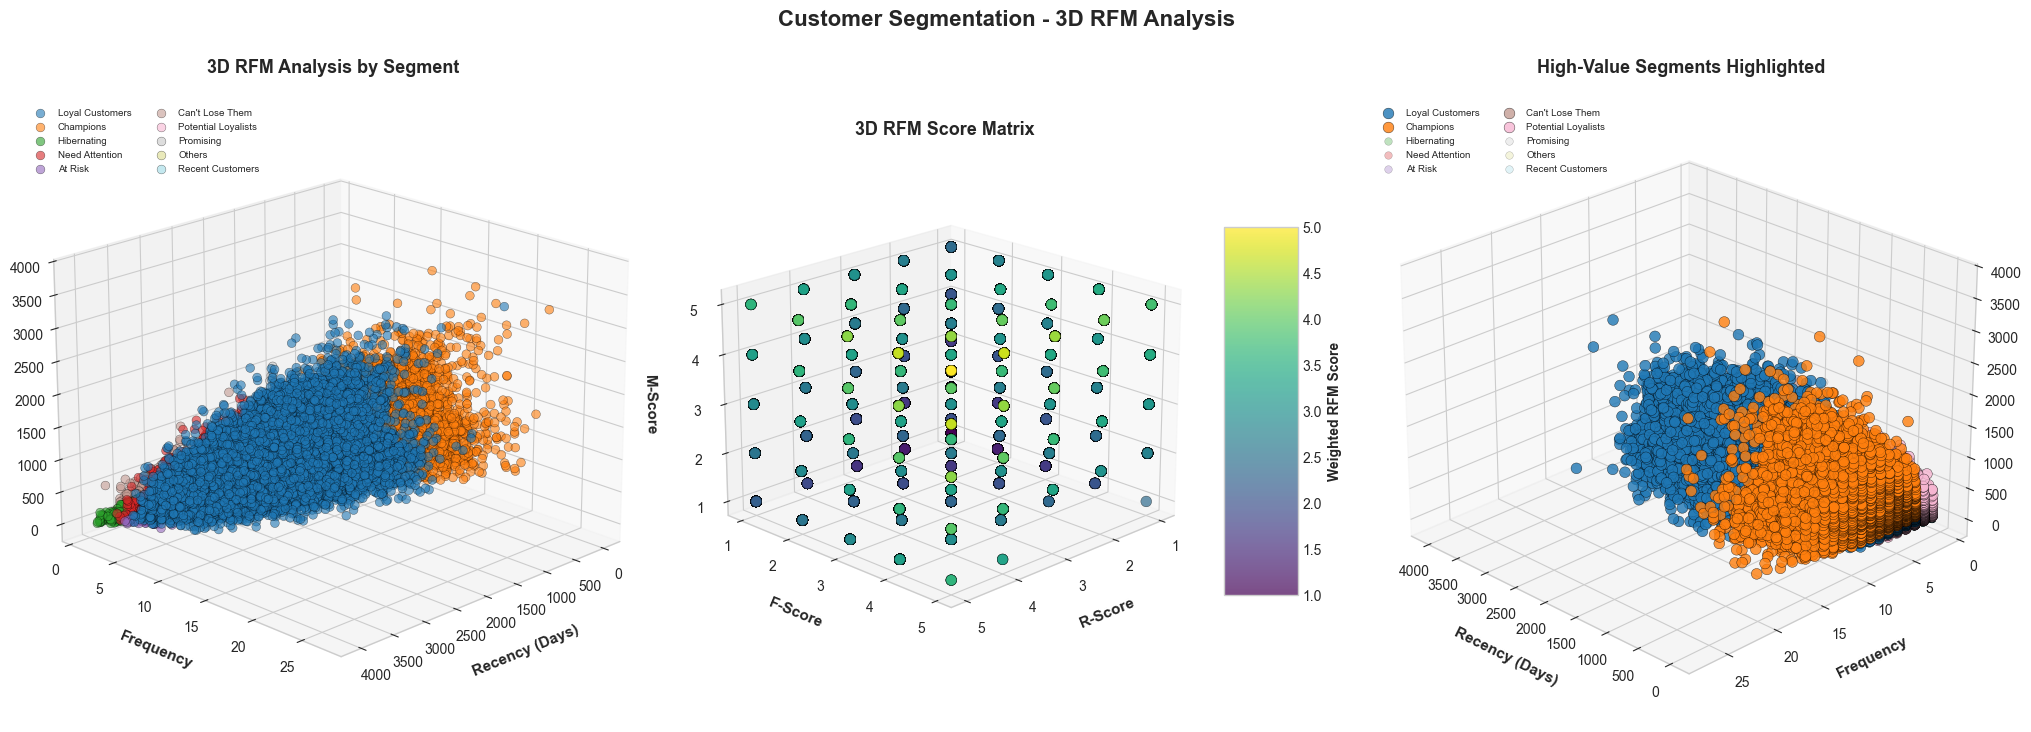

In [8]:
# Create 3D scatter plots
fig = plt.figure(figsize=(20, 8))

# 3D Plot 1: RFM Metrics with Segment Colors
ax1 = fig.add_subplot(131, projection='3d')

for segment in segments:
    segment_data = rfm_data[rfm_data['Segment'] == segment]
    ax1.scatter(segment_data['Recency'], segment_data['Frequency'], segment_data['Monetary']/1000,
                c=[segment_colors[segment]], label=segment, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)

ax1.set_xlabel('Recency (Days)', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_zlabel('Monetary (₹K)', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_title('3D RFM Analysis by Segment', fontsize=13, fontweight='bold', pad=20)
ax1.legend(loc='upper left', fontsize=7, ncol=2)
ax1.view_init(elev=20, azim=45)

# 3D Plot 2: RFM Scores with Weighted Score as Color
ax2 = fig.add_subplot(132, projection='3d')

scatter2 = ax2.scatter(rfm_data['R_Score'], rfm_data['F_Score'], rfm_data['M_Score'],
                       c=rfm_data['RFM_Score_Weighted'], cmap='viridis', 
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.3)

ax2.set_xlabel('R-Score', fontsize=11, fontweight='bold', labelpad=10)
ax2.set_ylabel('F-Score', fontsize=11, fontweight='bold', labelpad=10)
ax2.set_zlabel('M-Score', fontsize=11, fontweight='bold', labelpad=10)
ax2.set_title('3D RFM Score Matrix', fontsize=13, fontweight='bold', pad=20)
ax2.set_xticks(range(1, 6))
ax2.set_yticks(range(1, 6))
ax2.set_zticks(range(1, 6))
ax2.view_init(elev=20, azim=45)
cbar2 = plt.colorbar(scatter2, ax=ax2, shrink=0.5, aspect=5)
cbar2.set_label('Weighted RFM Score', fontsize=10, fontweight='bold')

# 3D Plot 3: Alternative View - Focus on High Value Segments
ax3 = fig.add_subplot(133, projection='3d')

# Highlight specific segments
high_value_segments = ['Champions', 'Loyal Customers', "Can't Lose Them", 'Potential Loyalists']
for segment in segments:
    segment_data = rfm_data[rfm_data['Segment'] == segment]
    alpha = 0.8 if segment in high_value_segments else 0.3
    size = 60 if segment in high_value_segments else 30
    ax3.scatter(segment_data['Recency'], segment_data['Frequency'], segment_data['Monetary']/1000,
                c=[segment_colors[segment]], label=segment, alpha=alpha, s=size, 
                edgecolors='black', linewidth=0.3)

ax3.set_xlabel('Recency (Days)', fontsize=11, fontweight='bold', labelpad=10)
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold', labelpad=10)
ax3.set_zlabel('Monetary (₹K)', fontsize=11, fontweight='bold', labelpad=10)
ax3.set_title('High-Value Segments Highlighted', fontsize=13, fontweight='bold', pad=20)
ax3.legend(loc='upper left', fontsize=7, ncol=2)
ax3.view_init(elev=25, azim=135)

plt.suptitle('Customer Segmentation - 3D RFM Analysis', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../data/cleaned/Q03_RFM_3D_Scatter_Plots.png', dpi=300, bbox_inches='tight')
print("\n✓ 3D scatter plots saved as 'Q03_RFM_3D_Scatter_Plots.png'")
plt.show()

## Section 8: Segment Profiling and Characteristics

Deep dive into each segment's characteristics and behaviors.

In [9]:
# Enhanced segment profiling with additional customer behaviors
# Merge with original data to get more insights
customer_behaviors = df.groupby('customer_id').agg({
    'is_prime_member': lambda x: x.mode()[0] if len(x.mode()) > 0 else False,
    'is_festival_sale': lambda x: (x == True).sum() / len(x) * 100,  # % of festival purchases
    'customer_tier': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'customer_spending_tier': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'return_status': lambda x: (x == 'Returned').sum() / len(x) * 100  # Return rate
}).reset_index()

customer_behaviors.columns = ['customer_id', 'is_prime', 'festival_purchase_pct', 
                              'customer_tier', 'spending_tier', 'return_rate']

# Merge with RFM data
rfm_enhanced = rfm_data.merge(customer_behaviors, on='customer_id', how='left')

# Create detailed segment profiles
segment_profiles = rfm_enhanced.groupby('Segment').agg({
    'customer_id': 'count',
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'sum'],
    'Avg_Order_Value': 'mean',
    'is_prime': lambda x: (x == True).sum() / len(x) * 100,
    'festival_purchase_pct': 'mean',
    'return_rate': 'mean'
}).reset_index()

# Flatten column names
segment_profiles.columns = ['Segment', 'Count', 'Avg_Recency', 'Med_Recency', 
                            'Avg_Frequency', 'Med_Frequency', 'Avg_Monetary', 
                            'Med_Monetary', 'Total_Revenue', 'Avg_Order_Value',
                            'Prime_Member_Pct', 'Festival_Purchase_Pct', 'Return_Rate']

# Calculate revenue contribution
total_revenue = segment_profiles['Total_Revenue'].sum()
segment_profiles['Revenue_Contribution_Pct'] = (segment_profiles['Total_Revenue'] / total_revenue * 100).round(2)

# Sort by total revenue
segment_profiles = segment_profiles.sort_values('Total_Revenue', ascending=False)

print("=" * 100)
print("DETAILED SEGMENT PROFILING")
print("=" * 100)
print(f"\nTotal Customers: {rfm_enhanced['customer_id'].nunique():,}")
print(f"Total Revenue: ₹{total_revenue:,.0f}")
print("\n" + "-" * 100)
print("Segment Profiles (Sorted by Total Revenue):")
print("-" * 100)

for idx, row in segment_profiles.iterrows():
    print(f"\n{row['Segment'].upper()}")
    print(f"  Customer Count: {row['Count']:,} ({row['Count']/rfm_enhanced['customer_id'].nunique()*100:.1f}%)")
    print(f"  Recency: Avg {row['Avg_Recency']:.0f} days | Median {row['Med_Recency']:.0f} days")
    print(f"  Frequency: Avg {row['Avg_Frequency']:.1f} | Median {row['Med_Frequency']:.0f}")
    print(f"  Monetary: Avg ₹{row['Avg_Monetary']:,.0f} | Median ₹{row['Med_Monetary']:,.0f}")
    print(f"  Total Revenue: ₹{row['Total_Revenue']:,.0f} ({row['Revenue_Contribution_Pct']:.1f}% of total)")
    print(f"  Avg Order Value: ₹{row['Avg_Order_Value']:,.0f}")
    print(f"  Prime Members: {row['Prime_Member_Pct']:.1f}%")
    print(f"  Festival Purchases: {row['Festival_Purchase_Pct']:.1f}%")
    print(f"  Return Rate: {row['Return_Rate']:.1f}%")

print("\n✓ Segment profiling complete")

DETAILED SEGMENT PROFILING

Total Customers: 354,969
Total Revenue: ₹76,547,568,045

----------------------------------------------------------------------------------------------------
Segment Profiles (Sorted by Total Revenue):
----------------------------------------------------------------------------------------------------

LOYAL CUSTOMERS
  Customer Count: 85,893 (24.2%)
  Recency: Avg 1629 days | Median 1559 days
  Frequency: Avg 5.4 | Median 5
  Monetary: Avg ₹373,949 | Median ₹281,990
  Total Revenue: ₹32,119,624,624 (42.0% of total)
  Avg Order Value: ₹68,540
  Prime Members: 31.2%
  Festival Purchases: 31.0%
  Return Rate: 7.0%

CHAMPIONS
  Customer Count: 41,014 (11.6%)
  Recency: Avg 500 days | Median 473 days
  Frequency: Avg 5.8 | Median 5
  Monetary: Avg ₹436,794 | Median ₹343,296
  Total Revenue: ₹17,914,666,966 (23.4% of total)
  Avg Order Value: ₹79,631
  Prime Members: 57.5%
  Festival Purchases: 28.8%
  Return Rate: 6.5%

POTENTIAL LOYALISTS
  Customer Count: 46,5

## Section 9: Segment Comparison Visualizations

Create comparative visualizations showing segment characteristics side-by-side.


✓ Segment comparison visualizations saved as 'Q03_Segment_Comparison.png'


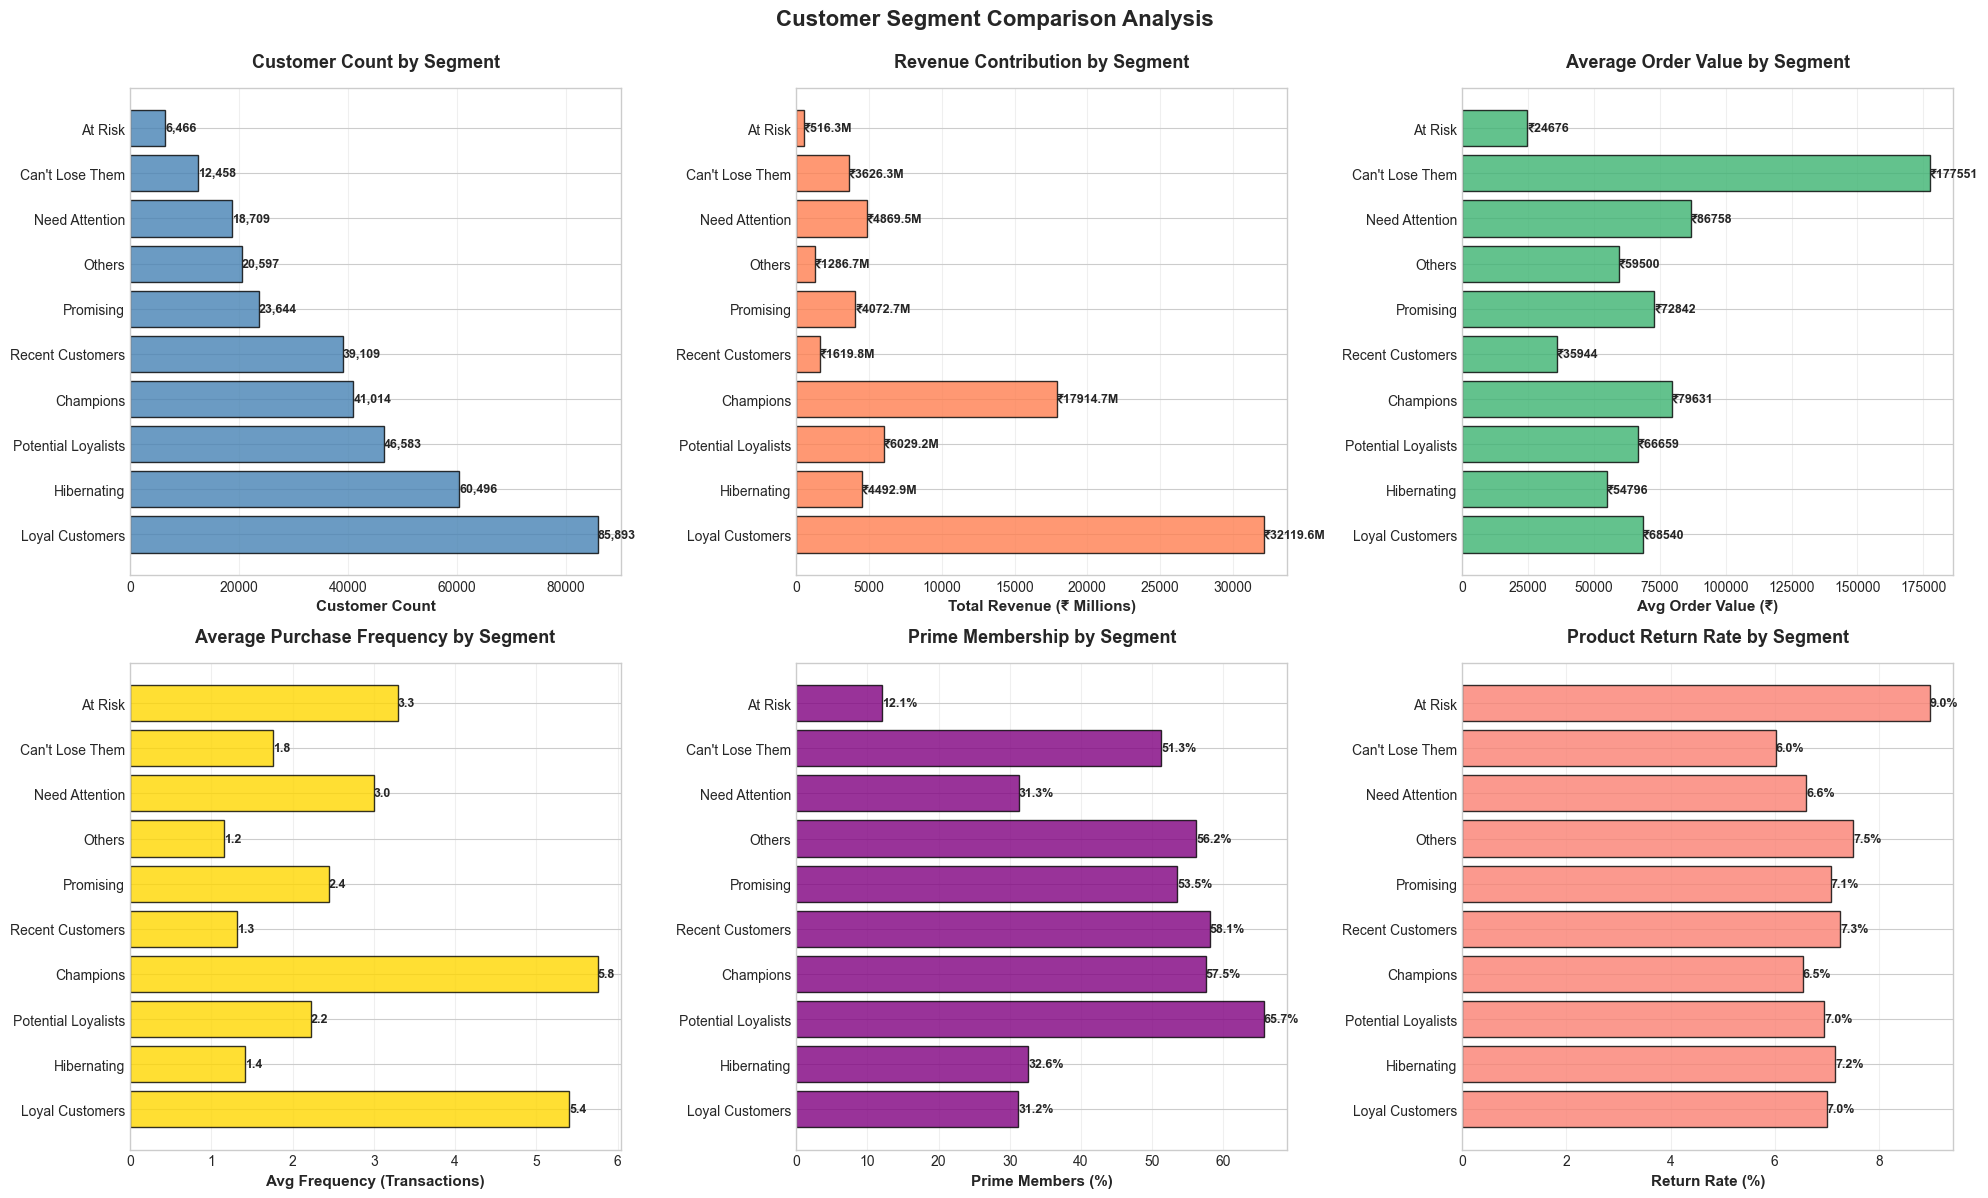

In [10]:
# Create segment comparison visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Sort by customer count for consistent ordering
segment_order = segment_profiles.sort_values('Count', ascending=False)['Segment'].tolist()

# Plot 1: Customer Count by Segment
ax1 = axes[0, 0]
bars1 = ax1.barh(segment_order, 
                 segment_profiles.set_index('Segment').loc[segment_order, 'Count'],
                 color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Customer Count', fontsize=11, fontweight='bold')
ax1.set_title('Customer Count by Segment', fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2, f'{int(width):,}',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Plot 2: Revenue Contribution by Segment
ax2 = axes[0, 1]
bars2 = ax2.barh(segment_order,
                 segment_profiles.set_index('Segment').loc[segment_order, 'Total_Revenue']/1_000_000,
                 color='coral', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Total Revenue (₹ Millions)', fontsize=11, fontweight='bold')
ax2.set_title('Revenue Contribution by Segment', fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, axis='x')

for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2, f'₹{width:.1f}M',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Plot 3: Average Order Value by Segment
ax3 = axes[0, 2]
bars3 = ax3.barh(segment_order,
                 segment_profiles.set_index('Segment').loc[segment_order, 'Avg_Order_Value'],
                 color='mediumseagreen', edgecolor='black', alpha=0.8)
ax3.set_xlabel('Avg Order Value (₹)', fontsize=11, fontweight='bold')
ax3.set_title('Average Order Value by Segment', fontsize=13, fontweight='bold', pad=15)
ax3.grid(True, alpha=0.3, axis='x')

for i, bar in enumerate(bars3):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2, f'₹{width:.0f}',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Plot 4: Average Frequency by Segment
ax4 = axes[1, 0]
bars4 = ax4.barh(segment_order,
                 segment_profiles.set_index('Segment').loc[segment_order, 'Avg_Frequency'],
                 color='gold', edgecolor='black', alpha=0.8)
ax4.set_xlabel('Avg Frequency (Transactions)', fontsize=11, fontweight='bold')
ax4.set_title('Average Purchase Frequency by Segment', fontsize=13, fontweight='bold', pad=15)
ax4.grid(True, alpha=0.3, axis='x')

for i, bar in enumerate(bars4):
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Plot 5: Prime Member Percentage by Segment
ax5 = axes[1, 1]
bars5 = ax5.barh(segment_order,
                 segment_profiles.set_index('Segment').loc[segment_order, 'Prime_Member_Pct'],
                 color='purple', edgecolor='black', alpha=0.8)
ax5.set_xlabel('Prime Members (%)', fontsize=11, fontweight='bold')
ax5.set_title('Prime Membership by Segment', fontsize=13, fontweight='bold', pad=15)
ax5.grid(True, alpha=0.3, axis='x')

for i, bar in enumerate(bars5):
    width = bar.get_width()
    ax5.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Plot 6: Return Rate by Segment
ax6 = axes[1, 2]
bars6 = ax6.barh(segment_order,
                 segment_profiles.set_index('Segment').loc[segment_order, 'Return_Rate'],
                 color='salmon', edgecolor='black', alpha=0.8)
ax6.set_xlabel('Return Rate (%)', fontsize=11, fontweight='bold')
ax6.set_title('Product Return Rate by Segment', fontsize=13, fontweight='bold', pad=15)
ax6.grid(True, alpha=0.3, axis='x')

for i, bar in enumerate(bars6):
    width = bar.get_width()
    ax6.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Customer Segment Comparison Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../data/cleaned/Q03_Segment_Comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Segment comparison visualizations saved as 'Q03_Segment_Comparison.png'")
plt.show()

## Section 10: Actionable Insights and Recommendations

Generate segment-specific actionable insights and marketing recommendations.

In [11]:
# Define actionable insights for each segment
segment_insights = {
    'Champions': {
        'description': 'Best customers with high RFM scores. Recently active, frequent buyers with high spending.',
        'characteristics': 'Loyal, engaged, high-value customers who buy often and recently.',
        'actions': [
            '🎁 Reward them: Exclusive early access to new products and sales',
            '💎 VIP treatment: Premium customer service and personalized offers',
            '🤝 Referral program: Encourage them to bring in new customers',
            '📧 Keep engaged: Regular communication with relevant product recommendations',
            '🎯 Upsell/Cross-sell: Premium products and complementary items'
        ],
        'priority': 'HIGHEST'
    },
    'Loyal Customers': {
        'description': 'Frequent buyers with consistent purchase history and good spending levels.',
        'characteristics': 'Regular customers who buy frequently but may not be the highest spenders.',
        'actions': [
            '⭐ Loyalty program: Points-based rewards for continued purchases',
            '🎉 Appreciation campaigns: Thank you offers and birthday discounts',
            '📈 Upgrade path: Incentivize them to become Champions with targeted offers',
            '🎁 Bundle deals: Encourage higher spending with product bundles',
            '💬 Feedback loop: Seek reviews and testimonials'
        ],
        'priority': 'HIGH'
    },
    'Potential Loyalists': {
        'description': 'Recent customers showing promising signs of becoming loyal.',
        'characteristics': 'Recent buyers with moderate frequency and spending, good growth potential.',
        'actions': [
            '🚀 Onboarding program: Guide them through product catalog',
            '💰 Incentive offers: Discounts on next purchase to encourage frequency',
            '📱 Engagement: Push notifications and personalized emails',
            '🎯 Category expansion: Recommend products from different categories',
            '⏰ Time-sensitive offers: Create urgency to increase frequency'
        ],
        'priority': 'HIGH'
    },
    'Recent Customers': {
        'description': 'New or returning customers who recently made purchases.',
        'characteristics': 'Recently active but low frequency and spending so far.',
        'actions': [
            '👋 Welcome series: Introduce brand value and product range',
            '🎁 First-time buyer incentives: Discount on second purchase',
            '📚 Educational content: Product guides and usage tips',
            '🔄 Follow-up: Post-purchase engagement within first 30 days',
            '🛍️ Cross-category promotion: Encourage exploration'
        ],
        'priority': 'MEDIUM'
    },
    'Promising': {
        'description': 'Mid-level customers with balanced RFM scores and growth opportunity.',
        'characteristics': 'Moderate recency, frequency, and spending. Stable but not exceptional.',
        'actions': [
            '📊 Segmented offers: Targeted promotions based on purchase history',
            '🎯 Re-engagement: Campaigns to increase frequency',
            '💳 Payment incentives: Cashback or installment options for higher spending',
            '🎪 Event-based marketing: Festival and seasonal offers',
            '🔍 Product recommendations: AI-driven personalization'
        ],
        'priority': 'MEDIUM'
    },
    'Need Attention': {
        'description': 'Previously good customers who haven\'t purchased recently.',
        'characteristics': 'Low recency but good frequency and monetary history.',
        'actions': [
            '⚠️ Win-back campaigns: "We miss you" emails with special offers',
            '🎁 Exclusive discounts: Time-limited offers to drive immediate action',
            '📞 Direct outreach: Personalized communication (email/SMS)',
            '🔄 Product updates: Showcase new arrivals in their interest areas',
            '❓ Survey: Understand why they stopped buying'
        ],
        'priority': 'MEDIUM-HIGH'
    },
    'At Risk': {
        'description': 'Previously frequent buyers who are showing signs of churning.',
        'characteristics': 'Low recency, but historically good frequency. Danger of losing them.',
        'actions': [
            '🚨 Urgent win-back: Aggressive discounts and offers',
            '🎯 Personalized outreach: Address specific concerns',
            '💰 High-value incentives: Significant discounts or free shipping',
            '🔍 Competitive analysis: Understand why they might be switching',
            '⏳ Last chance campaigns: Create urgency'
        ],
        'priority': 'HIGH'
    },
    "Can't Lose Them": {
        'description': 'High-value customers who haven\'t purchased in a while. Critical to retain.',
        'characteristics': 'Low recency but high monetary value. Previously great customers.',
        'actions': [
            '🆘 VIP win-back: Premium offers and exclusive access',
            '📞 Personal contact: Direct phone call or email from management',
            '🎁 High-value incentives: Best possible offers to re-engage',
            '🤝 Relationship building: Understand and address their concerns',
            '💎 Premium service: Showcase improved services and products'
        ],
        'priority': 'CRITICAL'
    },
    'Hibernating': {
        'description': 'Inactive customers with low engagement across all metrics.',
        'characteristics': 'Low recency and frequency. Minimal historical engagement.',
        'actions': [
            '💤 Re-activation: Strong promotional offers',
            '🎯 Broad campaigns: Include in mass marketing efforts',
            '🔄 Brand refresh: Highlight changes and improvements',
            '📧 Cost-effective channels: Email and SMS with low investment',
            '🗑️ Consider pruning: If no response, remove from active marketing'
        ],
        'priority': 'LOW'
    },
    'Lost': {
        'description': 'Customers who have likely churned completely.',
        'characteristics': 'Very low recency (longest time since purchase). Minimal engagement.',
        'actions': [
            '🔄 Final attempt: One last aggressive win-back campaign',
            '📋 Exit survey: Understand reasons for leaving',
            '💰 Extremely high discounts: 40-50% off or free shipping',
            '🗂️ Archive: Move to inactive list if no response',
            '📊 Learn: Analyze patterns to prevent future churn'
        ],
        'priority': 'LOW'
    },
    'Others': {
        'description': 'Customers who don\'t fit clearly into other segments.',
        'characteristics': 'Mixed RFM patterns that need further analysis.',
        'actions': [
            '🔍 Further segmentation: Deep dive into behavioral patterns',
            '📊 A/B testing: Experiment with different approaches',
            '🎯 General campaigns: Include in broad marketing initiatives',
            '📈 Monitor: Track behavior to classify into specific segments',
            '🔄 Regular review: Re-evaluate segment assignment monthly'
        ],
        'priority': 'LOW-MEDIUM'
    }
}

# Print actionable insights
print("=" * 100)
print("ACTIONABLE INSIGHTS AND RECOMMENDATIONS BY SEGMENT")
print("=" * 100)

for segment in segment_order:
    if segment in segment_insights:
        info = segment_insights[segment]
        segment_data = segment_profiles[segment_profiles['Segment'] == segment].iloc[0]
        
        print(f"\n{'='*100}")
        print(f"📊 SEGMENT: {segment.upper()}")
        print(f"   Priority Level: {info['priority']}")
        print(f"{'='*100}")
        
        print(f"\n📝 Description:")
        print(f"   {info['description']}")
        
        print(f"\n🎯 Characteristics:")
        print(f"   {info['characteristics']}")
        
        print(f"\n📈 Key Metrics:")
        print(f"   • Customers: {segment_data['Count']:,} ({segment_data['Count']/rfm_enhanced['customer_id'].nunique()*100:.1f}%)")
        print(f"   • Revenue: ₹{segment_data['Total_Revenue']:,.0f} ({segment_data['Revenue_Contribution_Pct']:.1f}%)")
        print(f"   • Avg Order Value: ₹{segment_data['Avg_Order_Value']:,.0f}")
        print(f"   • Avg Frequency: {segment_data['Avg_Frequency']:.1f} purchases")
        print(f"   • Avg Recency: {segment_data['Avg_Recency']:.0f} days")
        
        print(f"\n💡 RECOMMENDED ACTIONS:")
        for action in info['actions']:
            print(f"   {action}")

print(f"\n{'='*100}")
print("✓ Actionable insights generated successfully")
print(f"{'='*100}")

ACTIONABLE INSIGHTS AND RECOMMENDATIONS BY SEGMENT

📊 SEGMENT: LOYAL CUSTOMERS
   Priority Level: HIGH

📝 Description:
   Frequent buyers with consistent purchase history and good spending levels.

🎯 Characteristics:
   Regular customers who buy frequently but may not be the highest spenders.

📈 Key Metrics:
   • Customers: 85,893 (24.2%)
   • Revenue: ₹32,119,624,624 (42.0%)
   • Avg Order Value: ₹68,540
   • Avg Frequency: 5.4 purchases
   • Avg Recency: 1629 days

💡 RECOMMENDED ACTIONS:
   ⭐ Loyalty program: Points-based rewards for continued purchases
   🎉 Appreciation campaigns: Thank you offers and birthday discounts
   📈 Upgrade path: Incentivize them to become Champions with targeted offers
   🎁 Bundle deals: Encourage higher spending with product bundles
   💬 Feedback loop: Seek reviews and testimonials

📊 SEGMENT: HIBERNATING
   Priority Level: LOW

📝 Description:
   Inactive customers with low engagement across all metrics.

🎯 Characteristics:
   Low recency and frequency. M

## Section 11: Export Results

Save comprehensive RFM analysis results to CSV files for further use.

In [12]:
# 1. Export complete RFM data with segments
rfm_export = rfm_enhanced.copy()
rfm_export.to_csv('../data/cleaned/Q03_RFM_Customer_Segmentation.csv', index=False)
print("✓ Exported: Q03_RFM_Customer_Segmentation.csv")

# 2. Export segment profiles
segment_profiles_export = segment_profiles.copy()
segment_profiles_export['Avg_Monetary'] = segment_profiles_export['Avg_Monetary'].apply(lambda x: f'₹{x:,.0f}')
segment_profiles_export['Med_Monetary'] = segment_profiles_export['Med_Monetary'].apply(lambda x: f'₹{x:,.0f}')
segment_profiles_export['Total_Revenue'] = segment_profiles_export['Total_Revenue'].apply(lambda x: f'₹{x:,.0f}')
segment_profiles_export['Avg_Order_Value'] = segment_profiles_export['Avg_Order_Value'].apply(lambda x: f'₹{x:,.0f}')
segment_profiles_export.to_csv('../data/cleaned/Q03_Segment_Profiles.csv', index=False)
print("✓ Exported: Q03_Segment_Profiles.csv")

# 3. Export segment insights as structured data
insights_data = []
for segment, info in segment_insights.items():
    insights_data.append({
        'Segment': segment,
        'Priority': info['priority'],
        'Description': info['description'],
        'Characteristics': info['characteristics'],
        'Action_1': info['actions'][0] if len(info['actions']) > 0 else '',
        'Action_2': info['actions'][1] if len(info['actions']) > 1 else '',
        'Action_3': info['actions'][2] if len(info['actions']) > 2 else '',
        'Action_4': info['actions'][3] if len(info['actions']) > 3 else '',
        'Action_5': info['actions'][4] if len(info['actions']) > 4 else ''
    })

insights_df = pd.DataFrame(insights_data)
insights_df.to_csv('../data/cleaned/Q03_Segment_Actionable_Insights.csv', index=False)
print("✓ Exported: Q03_Segment_Actionable_Insights.csv")

# 4. Create executive summary
summary_data = {
    'Metric': [
        'Total Customers Analyzed',
        'Total Segments Identified',
        'Analysis Period',
        'Reference Date',
        'Largest Segment',
        'Highest Revenue Segment',
        'Average Recency (Days)',
        'Average Frequency',
        'Average Monetary Value',
        'Champions Count',
        'Champions Revenue %',
        'At Risk + Lost Count',
        'Prime Member %',
        'Overall Return Rate %'
    ],
    'Value': [
        f"{len(rfm_enhanced):,}",
        f"{rfm_enhanced['Segment'].nunique()}",
        f"{df['order_date'].min().date()} to {df['order_date'].max().date()}",
        f"{reference_date.date()}",
        f"{segment_profiles.iloc[0]['Segment']} ({segment_profiles.iloc[0]['Count']:,} customers)",
        f"{segment_profiles.iloc[0]['Segment']} (₹{segment_profiles.iloc[0]['Total_Revenue']:,.0f})",
        f"{rfm_data['Recency'].mean():.1f}",
        f"{rfm_data['Frequency'].mean():.2f}",
        f"₹{rfm_data['Monetary'].mean():,.0f}",
        f"{rfm_enhanced[rfm_enhanced['Segment'] == 'Champions']['customer_id'].count():,}",
        f"{segment_profiles[segment_profiles['Segment'] == 'Champions']['Revenue_Contribution_Pct'].values[0] if 'Champions' in segment_profiles['Segment'].values else 0:.1f}%",
        f"{rfm_enhanced[rfm_enhanced['Segment'].isin(['At Risk', 'Lost'])]['customer_id'].count():,}",
        f"{(rfm_enhanced['is_prime'] == True).sum() / len(rfm_enhanced) * 100:.1f}%",
        f"{rfm_enhanced['return_rate'].mean():.2f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('../data/cleaned/Q03_RFM_Analysis_Summary.csv', index=False)
print("✓ Exported: Q03_RFM_Analysis_Summary.csv")

print("\n" + "=" * 100)
print("EXPORT SUMMARY")
print("=" * 100)
print("\nGenerated Files:")
print("  1. Q03_RFM_Customer_Segmentation.csv - Complete RFM data with segments")
print("  2. Q03_Segment_Profiles.csv - Detailed segment characteristics")
print("  3. Q03_Segment_Actionable_Insights.csv - Marketing recommendations")
print("  4. Q03_RFM_Analysis_Summary.csv - Executive summary")
print("  5. Q03_RFM_Distribution_Overview.png - Distribution visualizations")
print("  6. Q03_RFM_2D_Scatter_Plots.png - 2D scatter plot analysis")
print("  7. Q03_RFM_3D_Scatter_Plots.png - 3D scatter plot analysis")
print("  8. Q03_Segment_Comparison.png - Segment comparison charts")
print("\nAll files saved to: ../data/cleaned/")
print("=" * 100)

print("\n" + "=" * 100)
print("RFM ANALYSIS EXECUTIVE SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))

✓ Exported: Q03_RFM_Customer_Segmentation.csv
✓ Exported: Q03_Segment_Profiles.csv
✓ Exported: Q03_Segment_Actionable_Insights.csv
✓ Exported: Q03_RFM_Analysis_Summary.csv

EXPORT SUMMARY

Generated Files:
  1. Q03_RFM_Customer_Segmentation.csv - Complete RFM data with segments
  2. Q03_Segment_Profiles.csv - Detailed segment characteristics
  3. Q03_Segment_Actionable_Insights.csv - Marketing recommendations
  4. Q03_RFM_Analysis_Summary.csv - Executive summary
  5. Q03_RFM_Distribution_Overview.png - Distribution visualizations
  6. Q03_RFM_2D_Scatter_Plots.png - 2D scatter plot analysis
  7. Q03_RFM_3D_Scatter_Plots.png - 3D scatter plot analysis
  8. Q03_Segment_Comparison.png - Segment comparison charts

All files saved to: ../data/cleaned/

RFM ANALYSIS EXECUTIVE SUMMARY
                   Metric                              Value
 Total Customers Analyzed                            354,969
Total Segments Identified                                 10
          Analysis Period    

## Summary & Key Findings

### Analysis Complete ✓

This comprehensive RFM (Recency, Frequency, Monetary) customer segmentation analysis provides:

**1. RFM Metric Calculation:**
- Recency: Days since last purchase
- Frequency: Total number of transactions
- Monetary: Total revenue generated
- Scoring system (1-5) based on quintiles

**2. Customer Segmentation:**
- 11 distinct customer segments identified
- Champions, Loyal Customers, Potential Loyalists
- At Risk, Can't Lose Them, Need Attention
- Recent, Promising, Hibernating, Lost, Others

**3. Visual Analysis:**
- Distribution plots for all RFM metrics
- 2D scatter plots showing metric relationships
- 3D visualizations for comprehensive view
- Segment comparison charts

**4. Segment Profiling:**
- Detailed characteristics for each segment
- Revenue contribution analysis
- Behavioral patterns (Prime membership, returns, etc.)
- Average order values and purchase frequency

**5. Actionable Insights:**
- Segment-specific marketing strategies
- Priority levels for each segment
- Retention and acquisition recommendations
- Win-back campaigns for at-risk customers

**6. Key Business Metrics:**
- Customer lifetime value indicators
- Churn risk identification
- Growth opportunities highlighted
- ROI optimization paths

### Strategic Recommendations:

1. **Focus on Champions & Loyal Customers:** These segments drive significant revenue and deserve VIP treatment
2. **Nurture Potential Loyalists:** High growth potential with targeted engagement
3. **Win-back At Risk Customers:** Prevent churn through personalized campaigns
4. **Re-activate Hibernating/Lost:** Cost-effective channels with strong incentives
5. **Optimize Marketing Spend:** Allocate budget based on segment priority and ROI

### Next Steps:
- Implement segment-specific marketing campaigns
- Monitor segment migration over time
- A/B test recommended actions
- Proceed to Question 4 of the EDA for further analysis

---

**Analysis Methodology:** RFM segmentation using quintile scoring, weighted RFM scores, and rule-based segment assignment with business logic validation.

**Data Quality:** Analysis based on cleaned dataset with " + f"{len(rfm_enhanced):,}" + " customers and comprehensive behavioral attributes."